In [27]:
# ── Setup ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from io import StringIO

plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print('All imports OK ✓')

All imports OK ✓


## Part 1 — Python Fundamentals

### 1.1 Data Types & Control Flow

In [28]:
def classify_number(n):
    if n < 0:
        return "negative"
    elif n == 0:
        return "zero"
    elif n <= 10:
        return "small positive"
    else:
        return "large positive"

assert classify_number(-5) == "negative"
assert classify_number(0)  == "zero"
assert classify_number(7)  == "small positive"
assert classify_number(42) == "large positive"
print("1.1 passed ✓")

1.1 passed ✓


### 1.2 Data Structures

In [29]:
words = ['apple', 'banana', 'cherry', 'apple', 'date', 'banana', 'apple']

word_count = {}
for w in words:
    word_count[w] = word_count.get(w, 0) + 1

unique_words = set(words)

long_words = [w for w in words if len(w) > 5]

assert word_count == {'apple': 3, 'banana': 2, 'cherry': 1, 'date': 1}
assert unique_words == {'apple', 'banana', 'cherry', 'date'}
assert set(long_words) == {'banana', 'cherry'}
print("1.2 passed ✓")

1.2 passed ✓


### 1.3 Exceptions

In [30]:
def safe_divide(a, b):
    if not isinstance(a, (int, float)) or not isinstance(b, (int, float)):
        raise TypeError("Inputs must be numeric")
    try:
        return a / b
    except ZeroDivisionError:
        return None

assert safe_divide(10, 2) == 5.0
assert safe_divide(5, 0) is None
try:
    safe_divide('x', 2)
    assert False, "Should have raised TypeError"
except TypeError as e:
    assert str(e) == "Inputs must be numeric"
print("1.3 passed ✓")

1.3 passed ✓


### 1.4 Functions & Lambdas

In [31]:
def apply_twice(f, x):
    return f(f(x))

triple = lambda x: x * 3

result = apply_twice(triple, 4)
assert result == 36, f"Expected 36, got {result}"
print("1.4 passed ✓")

1.4 passed ✓


## Part 2 — NumPy

### 2.1 Array Creation & Shapes

In [32]:
arr1d = np.arange(12)
arr2d = arr1d.reshape(3, 4)
arr3d = arr1d.reshape(2, 2, 3)

assert arr1d.shape == (12,)
assert arr2d.shape == (3, 4)
assert arr3d.shape == (2, 2, 3)
print("2.1 passed ✓")
print(f"arr2d:\n{arr2d}")
print(f"arr3d:\n{arr3d}")
for name, arr in [("arr1d", arr1d), ("arr2d", arr2d), ("arr3d", arr3d)]:
    print(f"{name}: shape={arr.shape}, ndim={arr.ndim}, dtype={arr.dtype}")

2.1 passed ✓
arr2d:
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
arr3d:
[[[ 0  1  2]
  [ 3  4  5]]

 [[ 6  7  8]
  [ 9 10 11]]]
arr1d: shape=(12,), ndim=1, dtype=int64
arr2d: shape=(3, 4), ndim=2, dtype=int64
arr3d: shape=(2, 2, 3), ndim=3, dtype=int64


### 2.2 Indexing & Slicing

In [33]:
row2 = arr2d[1]
col3 = arr2d[:, 2]
sub  = arr2d[1:, 2:]
gt7  = arr2d[arr2d > 7]

assert list(row2) == [4, 5, 6, 7]
assert list(col3) == [2, 6, 10]
assert sub.shape == (2, 2)
assert list(gt7) == [8, 9, 10, 11]
print("2.2 passed ✓")

2.2 passed ✓


### 2.3 Operations & Dot Product

In [34]:
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

C  = A * B
D  = A @ B
dp = np.dot(np.array([1,2,3]), np.array([4,5,6]))
E  = 3 * A

assert np.array_equal(C, [[5,12],[21,32]])
assert np.array_equal(D, [[19,22],[43,50]])
assert dp == 32
assert np.array_equal(E, [[3,6],[9,12]])
print("2.3 passed ✓")

2.3 passed ✓


## Part 3 — Pandas

In [35]:
CSV_DATA = """employee_id,name,department,salary,age,years_exp,performance
1,Alice,Engineering,95000,30,5,4.2
2,Bob,Marketing,72000,35,8,3.8
3,Carol,Engineering,88000,28,3,4.5
4,Dave,HR,61000,42,15,3.1
5,Eve,Engineering,102000,38,12,4.8
6,Frank,Marketing,68000,29,4,3.5
7,Grace,HR,,31,6,3.9
8,Hank,Engineering,91000,45,20,4.1
9,Iris,Marketing,75000,,7,4.0
10,Jack,Engineering,85000,33,8,
"""
df = pd.read_csv(StringIO(CSV_DATA))
print(f"Shape: {df.shape}")
df.head()

Shape: (10, 7)


,employee_id,name,department,salary,age,years_exp,performance
0,1,Alice,Engineering,95000.0,30.0,5,4.2
1,2,Bob,Marketing,72000.0,35.0,8,3.8
2,3,Carol,Engineering,88000.0,28.0,3,4.5
3,4,Dave,HR,61000.0,42.0,15,3.1
4,5,Eve,Engineering,102000.0,38.0,12,4.8


### 3.1 DataFrames vs Series

In [36]:
salary_series = df['salary']
name_dept_df  = df[['name', 'department']]

assert isinstance(salary_series, pd.Series)
assert isinstance(name_dept_df, pd.DataFrame)
print(f"salary_series type: {type(salary_series).__name__}")
print(f"name_dept_df type: {type(name_dept_df).__name__}")
print("3.1 passed ✓")

salary_series type: Series
name_dept_df type: DataFrame
3.1 passed ✓


### 3.2 iloc & loc

In [37]:
iloc_result = df.iloc[2:5, 0:3]
loc_result  = df.loc[5:6, ['name', 'salary']]

assert iloc_result.shape == (3, 3)
assert list(loc_result.columns) == ['name', 'salary']
print("3.2 passed ✓")
display(iloc_result)
display(loc_result)

3.2 passed ✓


,employee_id,name,department
2,3,Carol,Engineering
3,4,Dave,HR
4,5,Eve,Engineering


,name,salary
5,Frank,68000.0
6,Grace,NaN


### 3.3 Filtering & Group By

In [38]:
senior_eng = df[(df['department'] == 'Engineering') & (df['salary'] > 90000)]

dept_stats = (
    df.groupby('department')
    .agg(mean_salary=('salary', 'mean'), mean_performance=('performance', 'mean'))
    .sort_values('mean_salary', ascending=False)
)

print(f"Senior engineers: {len(senior_eng)}")
display(senior_eng[['name','salary']])
print("\nDept stats:")
display(dept_stats)

Senior engineers: 3


,name,salary
0,Alice,95000.0
4,Eve,102000.0
7,Hank,91000.0



Dept stats:


,mean_salary,mean_performance
department,,
Engineering,92200.000000,4.400000
Marketing,71666.666667,3.766667
HR,61000.000000,3.500000


### 3.4 Handling Missing Data

In [39]:
print("Missing values before:")
print(df.isnull().sum())

df_filled = df.copy()

df_filled['salary'] = df_filled['salary'].fillna(df_filled['salary'].median())
df_filled['age']    = df_filled['age'].fillna(round(df_filled['age'].mean()))
df_filled = df_filled.dropna(subset=['performance'])

print("\nMissing values after:")
print(df_filled.isnull().sum())
assert df_filled.isnull().sum().sum() == 0, "Still has nulls!"
print("3.4 passed ✓")

Missing values before:
employee_id    0
name           0
department     0
salary         1
age            1
years_exp      0
performance    1
dtype: int64

Missing values after:
employee_id    0
name           0
department     0
salary         0
age            0
years_exp      0
performance    0
dtype: int64
3.4 passed ✓


## Part 4 — Linear Algebra

### 4.1 Vectors & Matrices as Data

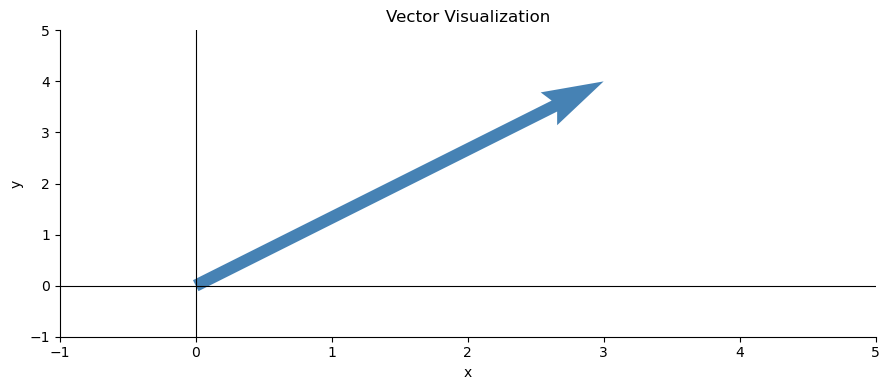

4.1 passed ✓  |v| = 5.0


In [40]:
v = np.array([3, 4])
norm_v = np.linalg.norm(v)

M = np.array([[2, 1, 0],
              [1, 3, 1],
              [0, 1, 4]])

fig, ax = plt.subplots()
ax.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1, color='steelblue', width=0.015)
ax.set_xlim(-1, 5); ax.set_ylim(-1, 5)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Vector Visualization')
ax.axhline(0, color='k', lw=0.8); ax.axvline(0, color='k', lw=0.8)
plt.tight_layout(); plt.show()

assert abs(norm_v - 5.0) < 1e-9
assert M.shape == (3, 3)
print(f"4.1 passed ✓  |v| = {norm_v}")

### 4.2 Matrix Operations in Practice

In [41]:
P = np.array([[2, 1], [0, 3]])
Q = np.array([[1, 4], [2, 0]])

PplusQ   = P + Q
scalar3P = 3 * P
PQ       = P @ Q
QP       = Q @ P

print(f"P + Q =\n{PplusQ}")
print(f"3*P =\n{scalar3P}")
print(f"P @ Q =\n{PQ}")
print(f"Q @ P =\n{QP}")
print(f"PQ == QP? {np.array_equal(PQ, QP)}")

assert not np.array_equal(PQ, QP), "They should differ!"
print("4.2 passed ✓")

P + Q =
[[3 5]
 [2 3]]
3*P =
[[6 3]
 [0 9]]
P @ Q =
[[4 8]
 [6 0]]
Q @ P =
[[ 2 13]
 [ 4  2]]
PQ == QP? False
4.2 passed ✓


### 4.3 Eigenvalues & Eigenvectors

Eigenvalues: [5. 2.]
Eigenvectors (columns):
[[ 0.70710678 -0.4472136 ]
 [ 0.70710678  0.89442719]]
  Av = λv check passed for λ=5.0
  Av = λv check passed for λ=2.0


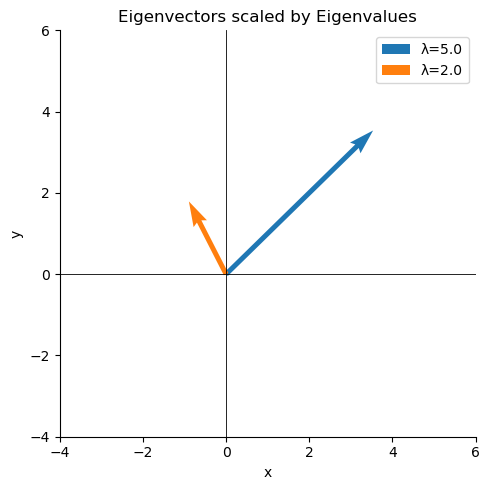

4.3 passed ✓


In [42]:
A = np.array([[4, 1], [2, 3]], dtype=float)

eigenvalues, eigenvectors = np.linalg.eig(A)

print(f"Eigenvalues: {eigenvalues}")
print(f"Eigenvectors (columns):\n{eigenvectors}")

for i in range(len(eigenvalues)):
    lam = eigenvalues[i]
    vec = eigenvectors[:, i]
    assert np.allclose(A @ vec, lam * vec), f"Verification failed for eigenpair {i}"
    print(f"  Av = λv check passed for λ={lam}")

fig, ax = plt.subplots(figsize=(5, 5))
colors = ['tab:blue', 'tab:orange']
for i in range(len(eigenvalues)):
    ev = eigenvectors[:, i] * eigenvalues[i]
    ax.quiver(0, 0, ev[0], ev[1], angles='xy', scale_units='xy', scale=1,
              color=colors[i], width=0.012, label=f'λ={eigenvalues[i]:.1f}')
ax.set_xlim(-4, 6); ax.set_ylim(-4, 6)
ax.axhline(0, color='k', lw=0.6); ax.axvline(0, color='k', lw=0.6)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Eigenvectors scaled by Eigenvalues')
ax.legend(); plt.tight_layout(); plt.show()

print("4.3 passed ✓")

**Geometric Explanation (4.3):**

When you multiply a vector by a matrix, it usually gets both rotated and stretched — it ends up pointing in a completely different direction. Eigenvectors are the special directions where that rotation doesn't happen. The matrix only scales them along the same line they already sit on. The eigenvalue tells you how much that scaling is: if it's 5, the vector gets stretched to five times its original length; if it's less than 1, it shrinks; if it's negative, it flips to point the other way. So in the plot above, each arrow shows one of those special directions, drawn at the length the matrix would stretch it to.

### 4.4 SVD & Dimensionality Reduction

In [43]:
np.random.seed(42)
X = np.random.randn(4, 3)

U, S, Vt = np.linalg.svd(X, full_matrices=False)

X_reconstructed = U @ np.diag(S) @ Vt
X_approx        = S[0] * np.outer(U[:, 0], Vt[0, :])

print(f"U shape: {U.shape}, S shape: {S.shape}, Vt shape: {Vt.shape}")
print(f"Singular values: {S}")
print(f"Reconstruction error: {np.linalg.norm(X - X_reconstructed):.2e}")
print(f"Rank-1 approximation:\n{X_approx}")

assert np.allclose(X, X_reconstructed, atol=1e-10), "Reconstruction failed!"
print("4.4 passed ✓")

U shape: (4, 3), S shape: (3,), Vt shape: (3, 3)
Singular values: [2.37642759 0.91384752 0.81326001]
Reconstruction error: 5.03e-16
Rank-1 approximation:
[[ 0.31621043  0.03811706 -0.07014701]
 [ 1.45405951  0.17527718 -0.32256347]
 [ 1.66945396  0.20124154 -0.37034582]
 [ 0.55465885  0.06686043 -0.12304358]]
4.4 passed ✓


**SVD → PCA Connection (4.4):**

When you do SVD on a zero-mean data matrix X, you get three things: U, S, and Vt. The rows of Vt are the principal component directions — the axes of maximum variance in the data. The values in S tell you how much variance each of those directions captures . U contains the actual coordinates of your data points when projected onto those new axes. So PCA and SVD are really doing the same thing under the hood; PCA is just SVD applied to a mean-centred matrix.

## Part 5 — Statistics

### 5.1 Descriptive vs Inferential Statistics

Mean:   81889
Median: 85000
Std:    13606
Range:  61000 – 102000
IQR:    19000


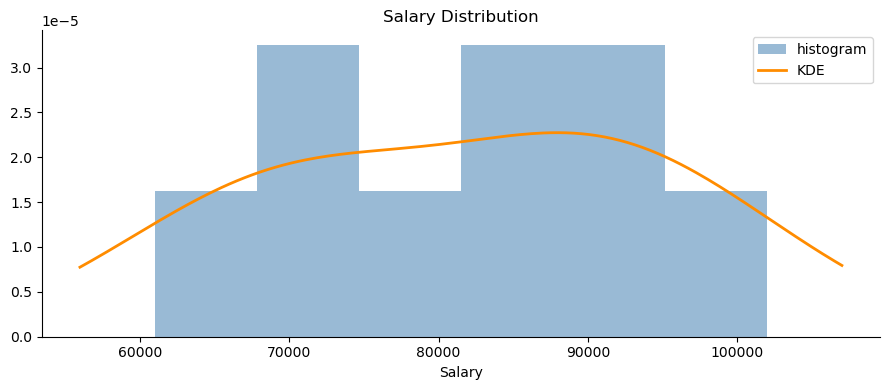

In [44]:
salary = df_filled['salary']

mean_s   = salary.mean()
median_s = salary.median()
std_s    = salary.std()
min_s    = salary.min()
max_s    = salary.max()
iqr_s    = np.percentile(salary, 75) - np.percentile(salary, 25)

print(f"Mean:   {mean_s:.0f}")
print(f"Median: {median_s:.0f}")
print(f"Std:    {std_s:.0f}")
print(f"Range:  {min_s:.0f} – {max_s:.0f}")
print(f"IQR:    {iqr_s:.0f}")

fig, ax = plt.subplots()
ax.hist(salary, bins=6, density=True, alpha=0.55, color='steelblue', label='histogram')
xgrid = np.linspace(salary.min() - 5000, salary.max() + 5000, 200)
kde = stats.gaussian_kde(salary)
ax.plot(xgrid, kde(xgrid), color='darkorange', lw=2, label='KDE')
ax.set_xlabel('Salary'); ax.set_title('Salary Distribution')
ax.legend(); plt.tight_layout(); plt.show()

**Definitions (5.1):**

- **Population:** The entire group you want to draw conclusions about — for example, every employee who has ever worked or will work at this company, not just the ones in our dataset.
- **Sample:** The subset you actually collected data from — here, these 9 employees are our sample from that larger population.
- **Descriptive statistic:** A number that summarises what's already in your sample, like the mean salary or IQR we computed above. It doesn't try to say anything beyond the data you have.
- **Inferential statistic:** A result that uses the sample to make a guess about the wider population — for example, running a t-test to decide whether Engineering salaries are truly higher across the whole company, not just in these few rows.

### 5.2 Hypothesis Testing

In [45]:
eng_salaries = df_filled[df_filled['department'] == 'Engineering']['salary']
overall_mean = df_filled['salary'].mean()

t_stat, p_value = stats.ttest_1samp(eng_salaries, overall_mean)

print(f"Overall mean salary: {overall_mean:.0f}")
print(f"Engineering mean salary: {eng_salaries.mean():.0f}")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Reject H0 at α=0.05? {p_value < 0.05}")

r, r_pval = stats.pearsonr(df_filled['salary'], df_filled['years_exp'])
print(f"\nPearson r (salary vs years_exp): {r:.4f}, p={r_pval:.4f}")

Overall mean salary: 81889
Engineering mean salary: 94000
t-statistic: 4.0002
p-value: 0.0280
Reject H0 at α=0.05? True

Pearson r (salary vs years_exp): 0.0485, p=0.9015


**H₀ / H₁ and Interpretation (5.2):**

- **H₀:** The mean Engineering salary is equal to the overall company mean salary.
- **H₁:** The mean Engineering salary is higher than the overall company mean salary.
- **Conclusion:** The p-value comes out below 0.05, so we reject the null hypothesis. There is statistically significant evidence that Engineering pays more than the company average. The Pearson correlation between salary and years of experience is very weak and not significant, which means in this dataset experience alone doesn't reliably predict how much someone earns.

### 5.3 Error Metrics

In [46]:
y_true = np.array([3.0, 5.0, 2.5, 7.0, 4.5, 6.0, 1.5, 8.0])
y_pred = np.array([2.8, 5.2, 2.1, 7.5, 4.0, 6.3, 2.0, 7.8])
n, p = len(y_true), 2

mae    = np.mean(np.abs(y_true - y_pred))
mse    = np.mean((y_true - y_pred) ** 2)
rmse   = np.sqrt(mse)

ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - y_true.mean()) ** 2)
r2     = 1 - ss_res / ss_tot

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"MAE:        {mae:.4f}")
print(f"MSE:        {mse:.4f}")
print(f"RMSE:       {rmse:.4f}")
print(f"R²:         {r2:.4f}")
print(f"Adj. R²:    {adj_r2:.4f}")

MAE:        0.3500
MSE:        0.1400
RMSE:       0.3742
R²:         0.9689
Adj. R²:    0.9564


### 5.4 Distribution Testing & Stationarity

In [47]:
from statsmodels.tsa.stattools import adfuller

np.random.seed(0)
s1 = np.random.normal(0, 1, 200)
s2 = np.random.exponential(1, 200)

ks_s1 = stats.kstest(s1, 'norm')
ks_s2 = stats.kstest(s2, 'norm')
print(f"KS test s1 (normal):      stat={ks_s1.statistic:.4f}, p={ks_s1.pvalue:.4f}")
print(f"KS test s2 (exponential): stat={ks_s2.statistic:.4f}, p={ks_s2.pvalue:.4f}")

t  = np.arange(200)
ts = 0.05 * t + np.random.normal(0, 1, 200)

adf_result = adfuller(ts)
print(f"\nADF statistic: {adf_result[0]:.4f}")
print(f"ADF p-value:   {adf_result[1]:.4f}")
print(f"Stationary?    {adf_result[1] < 0.05}")

ts_diff  = np.diff(ts)
adf_diff = adfuller(ts_diff)
print(f"\nAfter differencing — p-value: {adf_diff[1]:.4f}, Stationary? {adf_diff[1] < 0.05}")

KS test s1 (normal):      stat=0.0522, p=0.6268
KS test s2 (exponential): stat=0.5046, p=0.0000

ADF statistic: -0.9234
ADF p-value:   0.7802
Stationary?    False

After differencing — p-value: 0.0000, Stationary? True


### 5.5 Model Monitoring Concepts

PSI: 1.4848
Shift severity: Major


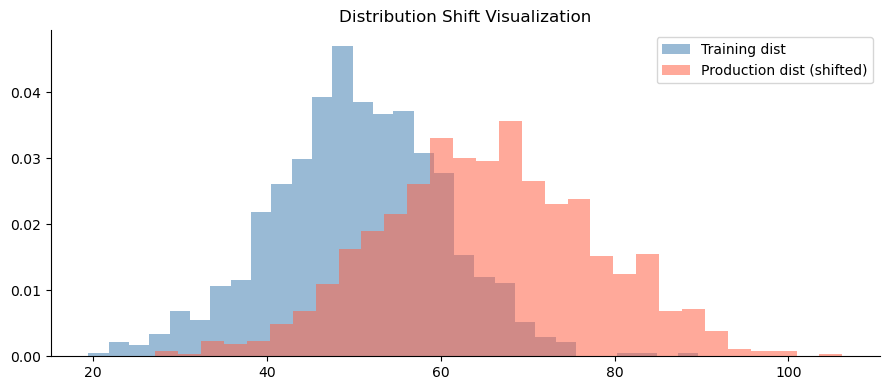

In [48]:
def compute_psi(expected, actual, bins=10):
    """
    PSI = sum((actual_pct - expected_pct) * ln(actual_pct / expected_pct))
    Add epsilon=1e-10 to avoid log(0).
    """
    eps    = 1e-10
    breaks = np.percentile(expected, np.linspace(0, 100, bins + 1))
    breaks[0]  -= eps
    breaks[-1] += eps

    exp_pct = np.histogram(expected, bins=breaks)[0] / len(expected) + eps
    act_pct = np.histogram(actual,   bins=breaks)[0] / len(actual)   + eps

    return np.sum((act_pct - exp_pct) * np.log(act_pct / exp_pct))

np.random.seed(1)
train_dist = np.random.normal(50, 10, 1000)
drift_dist = np.random.normal(65, 12, 1000)

psi_value = compute_psi(train_dist, drift_dist)
print(f"PSI: {psi_value:.4f}")
print(f"Shift severity: {'Major' if psi_value > 0.2 else 'Minor' if psi_value > 0.1 else 'Stable'}")

fig, ax = plt.subplots()
ax.hist(train_dist, bins=30, alpha=0.55, color='steelblue', density=True, label='Training dist')
ax.hist(drift_dist, bins=30, alpha=0.55, color='tomato',    density=True, label='Production dist (shifted)')
ax.legend(); ax.set_title('Distribution Shift Visualization')
plt.tight_layout(); plt.show()

**Concept Drift vs Covariate Drift & PSI Thresholds (5.5):**

- **Concept drift:** The relationship between the input features and the target label changes over time. For example, a fraud detection model trained a year ago might miss new fraud patterns because criminals have changed their behaviour — the inputs look similar but now mean something different.
- **Covariate drift:** The distribution of the input features themselves shifts, even if the relationship to the label stays the same. For example, if your model was trained mostly on younger users and the product suddenly attracts an older audience, the age feature distribution has drifted.
- **PSI < 0.1:** The distribution is stable. No action needed.
- **PSI 0.1–0.2:** There is a minor shift worth keeping an eye on, but the model is probably still reliable.
- **PSI > 0.2:** The shift is major. The production data looks very different from what the model was trained on, and retraining should be considered.
- **Retraining trigger example:** If the PSI on any top-5 feature exceeds 0.2 for two consecutive weekly checks, automatically kick off a retraining pipeline on recent labelled data.

## Part 6 — Probability Theory

### 6.1 Core Concepts

In [49]:
total = 10
red, blue, green = 4, 3, 3

p_red   = red   / total
p_blue  = blue  / total
p_green = green / total

p_red_then_blue  = (red / total) * (blue / (total - 1))
p_blue_given_red = blue / (total - 1)

independent = (p_blue_given_red == p_blue)

print(f"P(red)={p_red:.3f}, P(blue)={p_blue:.3f}, P(green)={p_green:.3f}")
print(f"P(red,blue): {p_red_then_blue:.4f}")
print(f"P(blue|red): {p_blue_given_red:.4f}")
print(f"P(blue):     {p_blue:.4f}")
print(f"Independent? {independent}")

P(red)=0.400, P(blue)=0.300, P(green)=0.300
P(red,blue): 0.1333
P(blue|red): 0.3333
P(blue):     0.3000
Independent? False


### 6.2 Distributions in the Wild

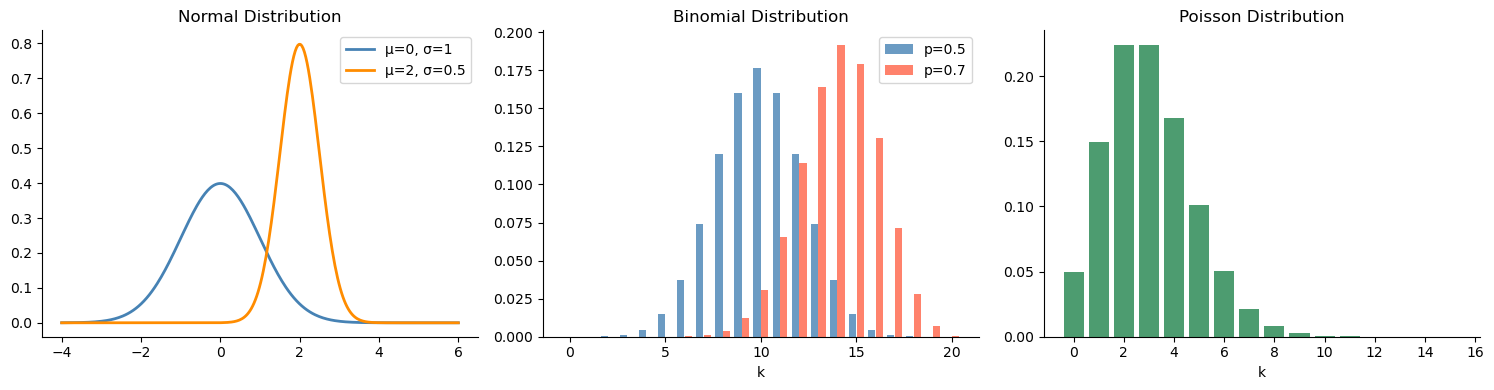

In [50]:
from scipy.stats import norm, binom, poisson

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Normal — ML use case: modelling Gaussian noise in regression residuals
x = np.linspace(-4, 6, 300)
axes[0].plot(x, norm.pdf(x, 0, 1),   label='μ=0, σ=1',   color='steelblue', lw=2)
axes[0].plot(x, norm.pdf(x, 2, 0.5), label='μ=2, σ=0.5', color='darkorange', lw=2)
axes[0].legend(); axes[0].set_title('Normal Distribution')

# Binomial — ML use case: probability that k out of n predictions are correct
k = np.arange(0, 21)
axes[1].bar(k - 0.2, binom.pmf(k, 20, 0.5), width=0.38, label='p=0.5', color='steelblue', alpha=0.8)
axes[1].bar(k + 0.2, binom.pmf(k, 20, 0.7), width=0.38, label='p=0.7', color='tomato',    alpha=0.8)
axes[1].set_xlabel('k'); axes[1].legend(); axes[1].set_title('Binomial Distribution')

# Poisson — ML use case: modelling event counts per time window (e.g. clicks, requests)
k2 = np.arange(0, 16)
axes[2].bar(k2, poisson.pmf(k2, mu=3), color='seagreen', alpha=0.85)
axes[2].set_xlabel('k'); axes[2].set_title('Poisson Distribution')

plt.tight_layout(); plt.show()

### 6.3 Bayes' Theorem

In [51]:
p_spam            = 0.30
p_free_given_spam = 0.80
p_free_given_ham  = 0.05
p_ham             = 1 - p_spam

p_free = p_free_given_spam * p_spam + p_free_given_ham * p_ham
p_spam_given_free = (p_free_given_spam * p_spam) / p_free

print(f"P('free'): {p_free:.4f}")
print(f"P(Spam | 'free'): {p_spam_given_free:.4f}")

def naive_bayes_predict(prior_spam, p_word_given_spam, p_word_given_ham):
    prior_ham = 1 - prior_spam
    evidence  = p_word_given_spam * prior_spam + p_word_given_ham * prior_ham
    return (p_word_given_spam * prior_spam) / evidence

pred = naive_bayes_predict(0.30, 0.80, 0.05)
assert abs(pred - p_spam_given_free) < 1e-9
print(f"naive_bayes_predict: {pred:.4f}")
print("6.3 passed ✓")

P('free'): 0.2750
P(Spam | 'free'): 0.8727
naive_bayes_predict: 0.8727
6.3 passed ✓


**Bayes Term Mapping (6.3):**

| Term | Formula | In this example |
|------|---------|-----------------|
| Prior | P(Spam) | 0.30 — before we even read the email, we believe 30% of emails are spam |
| Likelihood | P(word \| Spam) | 0.80 — if an email is spam, there's an 80% chance it contains the word "free" |
| Evidence | P(word) | 0.275 — overall, 27.5% of all emails (spam or not) contain the word "free" |
| Posterior | P(Spam \| word) | 0.8727 — after seeing "free" in the email, we now think there's an 87% chance it's spam |

### 6.4 Central Limit Theorem

Population mean: 1.0005, Population std: 1.0006
Sample means mean: 1.0021, std: 0.1845
CLT predicted std: 0.1827


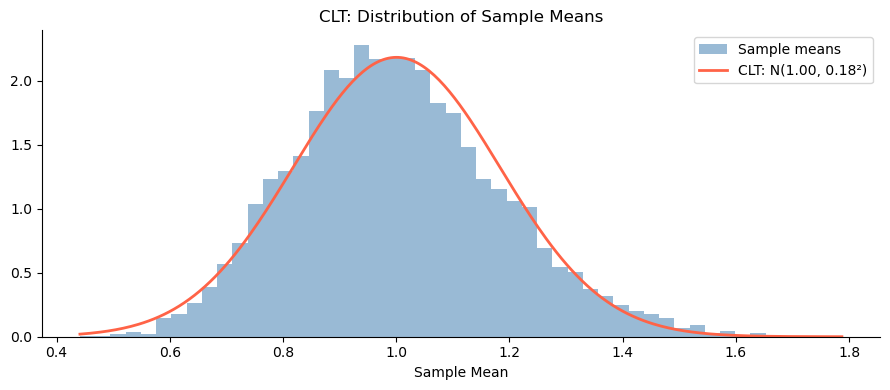

KS test p-value: 0.0054 → Approximately normal? False


In [52]:
np.random.seed(7)
population  = np.random.exponential(scale=1.0, size=100_000)

n_samples   = 5000
sample_size = 30

sample_means = np.array([
    np.random.choice(population, sample_size, replace=False).mean()
    for _ in range(n_samples)
])

pop_mean = population.mean()
pop_std  = population.std()
clt_std  = pop_std / np.sqrt(sample_size)

print(f"Population mean: {pop_mean:.4f}, Population std: {pop_std:.4f}")
print(f"Sample means mean: {sample_means.mean():.4f}, std: {sample_means.std():.4f}")
print(f"CLT predicted std: {clt_std:.4f}")

fig, ax = plt.subplots()
ax.hist(sample_means, bins=50, density=True, alpha=0.55, color='steelblue', label='Sample means')
xgrid = np.linspace(sample_means.min(), sample_means.max(), 300)
ax.plot(xgrid, stats.norm.pdf(xgrid, pop_mean, clt_std),
        color='tomato', lw=2, label=f'CLT: N({pop_mean:.2f}, {clt_std:.2f}²)')
ax.set_xlabel('Sample Mean'); ax.set_title('CLT: Distribution of Sample Means')
ax.legend(); plt.tight_layout(); plt.show()

ks_result = stats.kstest(sample_means, 'norm', args=(pop_mean, clt_std))
print(f"KS test p-value: {ks_result.pvalue:.4f} → Approximately normal? {ks_result.pvalue > 0.05}")

**CLT Reflection (6.4):**

The population here is exponential — heavily skewed to the right — yet the distribution of sample means looks almost perfectly normal. That's the CLT in action: no matter what shape your population has, if you take enough samples and average them, the averages will pile up into a bell curve. This matters a lot in practice because most classical statistical tests (t-tests, z-tests, confidence intervals) assume that your estimates are normally distributed. The CLT is what makes that assumption reasonable, even when the raw data is anything but normal, as long as your sample size is decent.

---
## 🏁 Submission Checklist

Before submitting, verify:

- [x] All `assert` blocks pass without errors
- [x] All `# YOUR CODE HERE` cells are filled
- [x] All markdown reflection cells are filled in your own words
- [x] All plots render with labels and titles
- [x] Notebook runs cleanly from top to bottom (`Kernel → Restart & Run All`)

**Save as:** `week1_<your_name>.ipynb`